In [39]:
!pip install tensorflow

In [40]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'          # silence TensorFlow logs

import numpy as np
import pandas as pd

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Regression models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

# Classification models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# Metrics — regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Metrics — classification
from sklearn.metrics import (accuracy_score, f1_score,
                             roc_auc_score, classification_report,
                             confusion_matrix)

# Neural network
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [41]:
#Setting random seeds ensures results are identical every time you run the script.
tf.random.set_seed(42)
np.random.seed(42)
print("FLIGHT DELAY PREDICTION — ML PIPELINE")


FLIGHT DELAY PREDICTION — ML PIPELINE


In [42]:
df = pd.read_csv('/content/Flight_delay-data.csv')

print(f"\n[DATA] Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"[DATA] Missing values: {df.isnull().sum().sum()}")
print(f"[DATA] Target (Arr_Delay) — min: {df['Arr_Delay'].min()}, "
      f"max: {df['Arr_Delay'].max()}, mean: {df['Arr_Delay'].mean():.1f} min")


[DATA] Shape: 3593 rows × 11 columns
[DATA] Missing values: 0
[DATA] Target (Arr_Delay) — min: 0, max: 180, mean: 69.8 min


In [43]:
# The dataset has one text column: Carrier (airline code like 'UA', 'DL').
# Machine learning models only understand numbers, so we convert it.
#
# Label Encoding assigns each unique carrier a unique integer:
#   UA → 0, DL → 1, AA → 2, ... etc.
# This is fine for tree-based models (Random Forest, Gradient Boosting) because
# they split on thresholds and don't treat the integers as ordered magnitudes.
# For neural networks we use One-Hot Encoding instead (see Section 6).

le = LabelEncoder()
df['Carrier_encoded'] = le.fit_transform(df['Carrier'])

# Define the feature columns (X) — everything except the raw Carrier text
# and the target column Arr_Delay.
FEATURE_COLS = [
    'Carrier_encoded',        # airline (label-encoded integer)
    'Airport_Distance',       # distance of route in km
    'Number_of_flights',      # total flights that day at origin airport
    'Weather',                # weather severity score (5–6 scale)
    'Support_Crew_Available', # ground crew headcount
    'Baggage_loading_time',   # minutes to load bags (strong predictor: r=0.78)
    'Late_Arrival_o',         # late arrival at origin in minutes (r=0.67)
    'Cleaning_o',             # cleaning delay at origin in minutes
    'Fueling_o',              # fueling delay at origin in minutes
    'Security_o',             # security delay at origin in minutes
]

In [44]:
X = df[FEATURE_COLS].values    # NumPy array of shape (3593, 10)
y_reg = df['Arr_Delay'].values # Regression target: continuous minutes (0–180)


In [45]:
y_clf = (df['Arr_Delay'] > 15).astype(int).values

print(f"\n[FEATURES] {len(FEATURE_COLS)} features selected")
print(f"[CLASS] Delayed (>15 min): {y_clf.sum()} / {len(y_clf)} "
      f"= {y_clf.mean()*100:.1f}%")




[FEATURES] 10 features selected
[CLASS] Delayed (>15 min): 3489 / 3593 = 97.1%


In [46]:
#First split

#You take ALL your data and split it like this:

# 60% → Train + Validation (keep for learning + tuning)
 #40% → Test (hide this for final exam)
X_trainval, X_test, y_reg_trainval, y_reg_test, y_clf_trainval, y_clf_test = \
    train_test_split(X, y_reg, y_clf,
                     test_size=0.20,
                     random_state=42,
                     stratify=y_clf)

In [47]:
#(0.25 of the 80% trainval ≈ 20% of the original total)-
#Second split
#Now you take the 60% part and split again:
#60% of total → Training (model learns here)
#20% of total → Validation (model is checked here)
X_train, X_val, y_reg_train, y_reg_val, y_clf_train, y_clf_val = \
    train_test_split(X_trainval, y_reg_trainval, y_clf_trainval,
                     test_size=0.25,
                     random_state=42,
                     stratify=y_clf_trainval)

In [48]:
print(f"\n[SPLIT] Train:      {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"[SPLIT] Validation: {X_val.shape[0]} rows ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"[SPLIT] Test:       {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.0f}%)")


[SPLIT] Train:      2155 rows (60%)
[SPLIT] Validation: 719 rows (20%)
[SPLIT] Test:       719 rows (20%)


In [49]:

def regression_report(name, y_true, y_pred, split='Test'):
    """Print MAE, RMSE and R² for a regression model."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"  [{split}] MAE={mae:.2f} min | RMSE={rmse:.2f} min | R²={r2:.4f}")
    return {'mae': mae, 'rmse': rmse, 'r2': r2}

def classification_report_short(name, y_true, y_pred, y_prob, split='Test'):
    """Print accuracy, F1, and ROC-AUC for a classification model."""
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_prob)
    print(f"  [{split}] Accuracy={acc*100:.2f}% | F1={f1:.4f} | ROC-AUC={auc:.4f}")
    return {'accuracy': acc, 'f1': f1, 'auc': auc}

In [50]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit + transform training
X_val_sc   = scaler.transform(X_val)         # transform only — no fit
X_test_sc  = scaler.transform(X_test)        # transform only — no fit

In [51]:
# One-Hot Encoding for the Carrier column in the neural network.
# Instead of UA=0, DL=1, AA=2 (which implies an ordinal relationship),
# OHE creates a separate binary column for each carrier:
#   UA → [1,0,0,...], DL → [0,1,0,...], AA → [0,0,1,...] etc.
# This removes false magnitude ordering.
carrier_ohe = pd.get_dummies(df['Carrier'])
carrier_cols = carrier_ohe.columns.tolist()

# Rebuild feature arrays with OHE carriers for the neural network
df_ohe = pd.concat([df[FEATURE_COLS[1:]], carrier_ohe], axis=1)  # drop label-encoded col
X_ohe = df_ohe.values

X_ohe_trainval, X_ohe_test = train_test_split(X_ohe, test_size=0.20,
                                               random_state=42, stratify=y_clf)
X_ohe_train, X_ohe_val     = train_test_split(X_ohe_trainval, test_size=0.25,
                                               random_state=42,
                                               stratify=y_clf_trainval)

scaler_ohe = StandardScaler()
X_ohe_train_sc = scaler_ohe.fit_transform(X_ohe_train)
X_ohe_val_sc   = scaler_ohe.transform(X_ohe_val)
X_ohe_test_sc  = scaler_ohe.transform(X_ohe_test)


#Regression Model

**Linear Regression**

In [52]:
print("\n Linear Regression ")
lr_reg = LinearRegression()
lr_reg.fit(X_train, y_reg_train)

val_preds_lr  = lr_reg.predict(X_val)
test_preds_lr = lr_reg.predict(X_test)
regression_report("LinearReg", y_reg_val,  val_preds_lr,  split='Val ')
regression_report("LinearReg", y_reg_test, test_preds_lr, split='Test')


 Linear Regression 
  [Val ] MAE=9.79 min | RMSE=12.24 min | R²=0.8304
  [Test] MAE=10.22 min | RMSE=13.06 min | R²=0.8039


{'mae': 10.22345107554621,
 'rmse': np.float64(13.061416871968053),
 'r2': 0.8038502648895058}

Random Forest Regressor

In [53]:
print("\n Random Forest Regressor")
rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_reg.fit(X_train, y_reg_train)

val_preds_rf  = rf_reg.predict(X_val)
test_preds_rf = rf_reg.predict(X_test)
regression_report("RF Reg", y_reg_val,  val_preds_rf,  split='Val ')
regression_report("RF Reg", y_reg_test, test_preds_rf, split='Test')


 Random Forest Regressor
  [Val ] MAE=9.88 min | RMSE=12.48 min | R²=0.8237
  [Test] MAE=10.25 min | RMSE=13.09 min | R²=0.8031


{'mae': 10.252670013889471,
 'rmse': np.float64(13.086987440050319),
 'r2': 0.8030815014653361}

Gradient Boosting Regressor

In [54]:
print("\n[Gradient Boosting Regressor")
gb_reg = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=42
)
gb_reg.fit(X_train, y_reg_train)

val_preds_gb  = gb_reg.predict(X_val)
test_preds_gb = gb_reg.predict(X_test)
regression_report("GB Reg", y_reg_val,  val_preds_gb,  split='Val ')
regression_report("GB Reg", y_reg_test, test_preds_gb, split='Test')


[Gradient Boosting Regressor
  [Val ] MAE=9.71 min | RMSE=12.42 min | R²=0.8254
  [Test] MAE=10.26 min | RMSE=13.05 min | R²=0.8041


{'mae': 10.262330009386268,
 'rmse': np.float64(13.053630150522011),
 'r2': 0.8040840692441072}

#Neural Network

In [58]:
# Architecture explanation:
#
# Input layer  — one neuron per feature (auto-inferred from input_shape)
# Hidden layer 1 — 128 neurons, ReLU activation
#               ReLU(x) = max(0, x): introduces non-linearity so the network
#               can learn curved decision boundaries, not just straight lines.
# BatchNormalization — normalises activations within a mini-batch to mean≈0,
#               std≈1. Speeds up training and stabilises it.
# Dropout(0.3)  — randomly zeroes 30% of neurons during each training step.
#               Forces the network to learn redundant representations,
#               preventing over-reliance on specific neurons (regularisation).
# Hidden layer 2 — 64 neurons, same pattern
# Hidden layer 3 — 32 neurons
# Output layer:
#   Regression     → 1 neuron, linear activation (output is a raw number)
#   Classification → 1 neuron, sigmoid activation (output is a probability 0–1)
#
# EarlyStopping: monitors validation loss; if it doesn't improve for
# 'patience' epochs, training stops and weights are restored to best epoch.
# This prevents overfitting without needing to guess the exact epoch count.

In [59]:
n_features_ohe = X_ohe_train_sc.shape[1]

def build_model(task='regression'):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(n_features_ohe,)),
        BatchNormalization(),
        Dropout(0.3),

        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),

        Dense(32, activation='relu'),
        Dropout(0.1),
    ])
    if task == 'regression':
        model.add(Dense(1, activation='linear'))   # unbounded output
        model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss='mse',           # Mean Squared Error
            metrics=['mae']       # Mean Absolute Error (human-readable)
        )
    else:
        model.add(Dense(1, activation='sigmoid'))  # output: P(delayed)
        model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss='binary_crossentropy',   # log-loss for binary classification
            metrics=['accuracy']
        )
    return model

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,             # wait 15 epochs before stopping
    restore_best_weights=True
)

In [61]:
print("\n  Searching over parameter grid on validation set...")

param_grid = [
    {'n': 200, 'lr': 0.05, 'depth': 4, 'sub': 0.8, 'leaf': 2},
    {'n': 300, 'lr': 0.05, 'depth': 5, 'sub': 0.8, 'leaf': 2},
    {'n': 400, 'lr': 0.03, 'depth': 4, 'sub': 0.8, 'leaf': 3},
    {'n': 500, 'lr': 0.02, 'depth': 4, 'sub': 0.7, 'leaf': 3},
    {'n': 300, 'lr': 0.05, 'depth': 6, 'sub': 0.8, 'leaf': 2},
    {'n': 400, 'lr': 0.05, 'depth': 5, 'sub': 0.9, 'leaf': 1},
    {'n': 600, 'lr': 0.01, 'depth': 5, 'sub': 0.8, 'leaf': 4},
]

best_val_mae, best_params, best_model = float('inf'), None, None

for p in param_grid:
    model = GradientBoostingRegressor(
        n_estimators=p['n'], learning_rate=p['lr'],
        max_depth=p['depth'], subsample=p['sub'],
        min_samples_leaf=p['leaf'], random_state=42
    )
    model.fit(X_train, y_reg_train)
    val_mae = mean_absolute_error(y_reg_val, model.predict(X_val))
    print(f"    n={p['n']:>3} lr={p['lr']} depth={p['depth']} "
          f"sub={p['sub']} leaf={p['leaf']}  → val MAE={val_mae:.4f}")
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_params  = p
        best_model   = model

print(f"\n  Best params: {best_params}")
print(f"  Best val MAE: {best_val_mae:.4f}")

print("\n  Results with best hyperparameters (GB + engineered features):")
regression_report('GB Reg Tuned', y_reg_val,  best_model.predict(X_val),  split='Val ')
regression_report('GB Reg Tuned', y_reg_test, best_model.predict(X_test), split='Test')


  Searching over parameter grid on validation set...
    n=200 lr=0.05 depth=4 sub=0.8 leaf=2  → val MAE=9.5053
    n=300 lr=0.05 depth=5 sub=0.8 leaf=2  → val MAE=9.6827
    n=400 lr=0.03 depth=4 sub=0.8 leaf=3  → val MAE=9.5716
    n=500 lr=0.02 depth=4 sub=0.7 leaf=3  → val MAE=9.5478
    n=300 lr=0.05 depth=6 sub=0.8 leaf=2  → val MAE=9.7561
    n=400 lr=0.05 depth=5 sub=0.9 leaf=1  → val MAE=9.6800
    n=600 lr=0.01 depth=5 sub=0.8 leaf=4  → val MAE=9.5223

  Best params: {'n': 200, 'lr': 0.05, 'depth': 4, 'sub': 0.8, 'leaf': 2}
  Best val MAE: 9.5053

  Results with best hyperparameters (GB + engineered features):
  [Val ] MAE=9.51 min | RMSE=12.13 min | R²=0.8333
  [Test] MAE=10.00 min | RMSE=12.69 min | R²=0.8147


{'mae': 10.00242487160086,
 'rmse': np.float64(12.693877616412223),
 'r2': 0.8147339857781265}

In [62]:
print("\nNeural Network — Regression")
nn_reg = build_model('regression')

history_reg = nn_reg.fit(
    X_ohe_train_sc, y_reg_train,
    validation_data=(X_ohe_val_sc, y_reg_val),
    epochs=150,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

nn_val_preds_reg  = nn_reg.predict(X_ohe_val_sc, verbose=0).flatten()
nn_test_preds_reg = nn_reg.predict(X_ohe_test_sc, verbose=0).flatten()
print(f"  Epochs trained: {len(history_reg.history['loss'])}")
regression_report("NN Reg", y_reg_val,  nn_val_preds_reg,  split='Val ')
regression_report("NN Reg", y_reg_test, nn_test_preds_reg, split='Test')


Neural Network — Regression
  Epochs trained: 44
  [Val ] MAE=9.78 min | RMSE=12.35 min | R²=0.8274
  [Test] MAE=10.14 min | RMSE=12.80 min | R²=0.8115


{'mae': 10.139674186706543,
 'rmse': np.float64(12.804564162958469),
 'r2': 0.8114889860153198}

**Regression Plots**

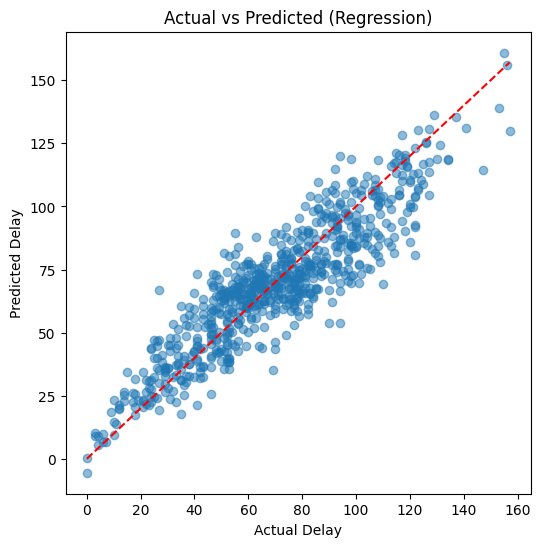

In [66]:
import matplotlib.pyplot as plt

# y_test_r = actual values
# y_pred_r = predicted values (from your NN or best model)

plt.figure(figsize=(6,6))
plt.scatter(y_reg_test, nn_test_preds_reg, alpha=0.5)
plt.xlabel("Actual Delay")
plt.ylabel("Predicted Delay")
plt.title("Actual vs Predicted (Regression)")
plt.plot([y_reg_test.min(), y_reg_test.max()],
         [y_reg_test.min(), y_reg_test.max()],
         'r--')  # perfect prediction line
plt.show()

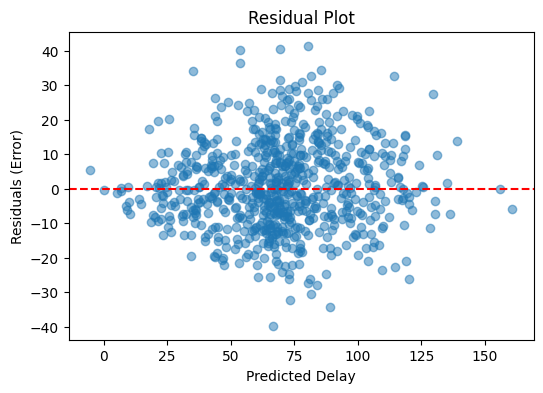

In [68]:
residuals = y_reg_test - nn_test_preds_reg

plt.figure(figsize=(6,4))
plt.scatter(nn_test_preds_reg, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Delay")
plt.ylabel("Residuals (Error)")
plt.title("Residual Plot")
plt.show()

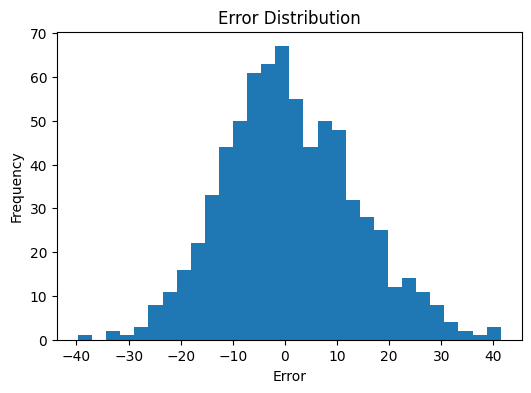

In [69]:
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30)
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.title("Error Distribution")
plt.show()